# Model B: Time-Series Forecasting (TensorFlow.js Version)

**Tujuan model:** Prediksi `total_expense` bulan berikutnya berdasarkan pola historis pengeluaran pengguna.

**Pendekatan yang benar (lag features):**
- Input: total_expense bulan N-1, N-2, N-3 + rolling mean
- Target: total_expense bulan N
- Split: berdasarkan `user_id` (bukan random baris) untuk mencegah data leakage temporal

**Perubahan dari versi sebelumnya:**
- Model XGBoost / GradientBoosting diganti dengan **Keras Sequential** (Dense regressor) yang ekuivalen secara fungsional, sehingga bisa di-export ke format TF.js.
- Model disimpan dalam format `model.json` + file `.bin` via `tfjs.converters.save_keras_model()`.
- `StandardScaler` (mean & std per fitur) diekspor sebagai `scaler_config.json` agar bisa direkonstruksi di frontend.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, json
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)
tf.random.set_seed(42)

OUTPUT_DIR ="/content/drive/MyDrive/Capstone Projek/models"
os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Setup selesai. TF version:", tf.__version__)

Setup selesai. TF version: 2.20.0


In [4]:
# ──────────────────────────────────────────────────────────────────────
# LOAD DATA
# ──────────────────────────────────────────────────────────────────────
df = pd.read_csv("/content/dataset_b_forecasting.csv")
print(f"Shape: {df.shape}")
print(f"Users: {df['user_id'].nunique():,} | Bulan per user: {df['bulan_index'].max()}")
print(f"\nStats kunci:")
print(df[["monthly_income","total_expense","expense_to_income_ratio",
          "savings_rate","current_total_balance"]].describe().round(0).to_string())

Shape: (230474, 17)
Users: 9,604 | Bulan per user: 24

Stats kunci:
       monthly_income  total_expense  expense_to_income_ratio  savings_rate  current_total_balance
count        230474.0       230473.0                 230473.0      230473.0               230473.0
mean        7808842.0      6016730.0                      1.0           0.0             35533682.0
std         7199830.0      4680621.0                      0.0           0.0             53702430.0
min           39794.0       879800.0                      0.0          -2.0                    0.0
25%         3388200.0      3150100.0                      1.0           0.0              4803900.0
50%         5521600.0      4953000.0                      1.0           0.0             14253800.0
75%         8433025.0      6775100.0                      1.0           0.0             42729000.0
max        62039800.0     37795500.0                      3.0           1.0            505276400.0


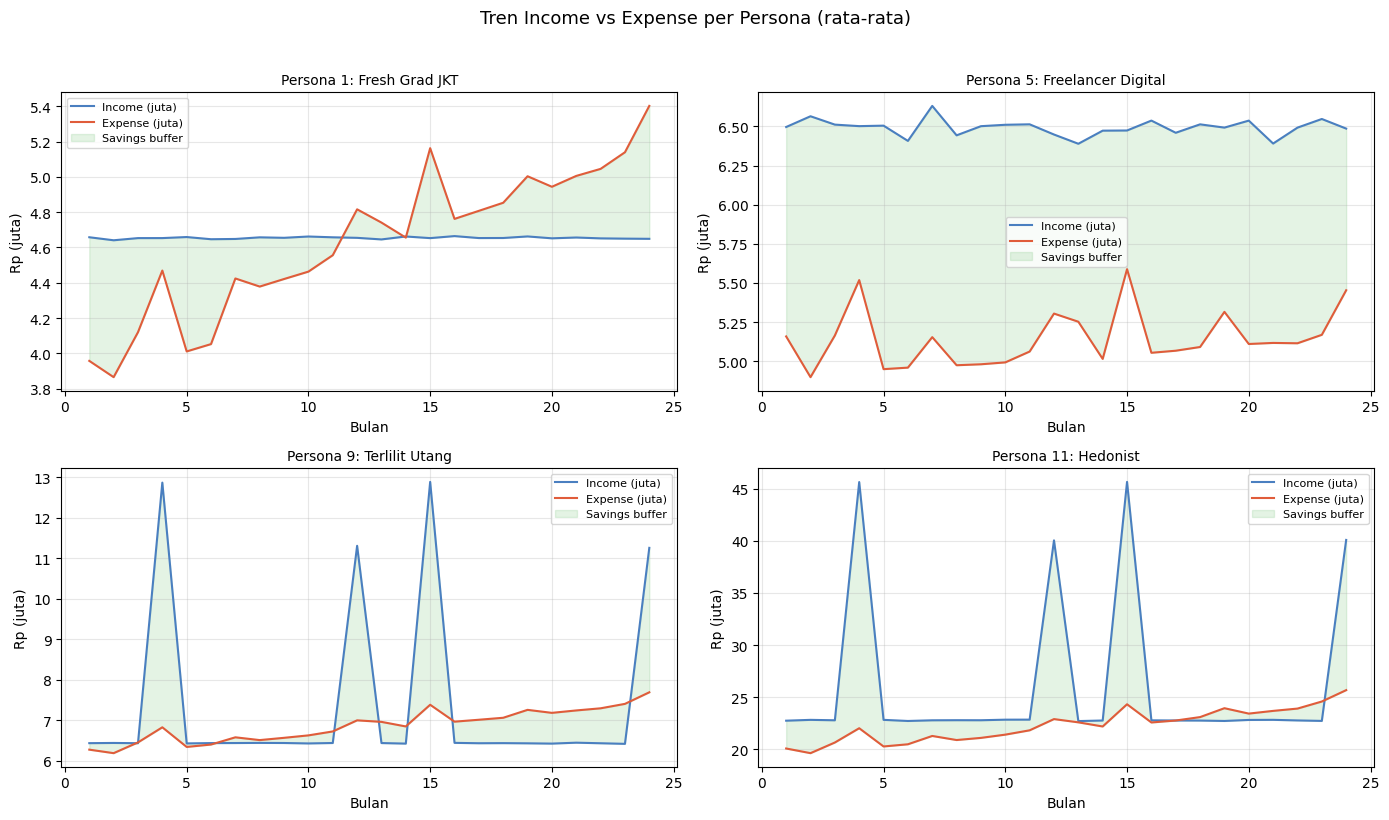

In [5]:
# ──────────────────────────────────────────────────────────────────────
# EDA — tren pengeluaran per persona
# ──────────────────────────────────────────────────────────────────────
persona_names = {
    1:"Fresh Grad JKT", 2:"Fresh Grad YK", 3:"Milenial Mapan", 4:"IRT Muda",
    5:"Freelancer Digital", 6:"PNS Gol III", 7:"Profesional Senior", 8:"Ojol",
    9:"Terlilit Utang", 10:"Karyawan Menengah", 11:"Hedonist", 12:"Ultra Hemat",
    13:"Fresh Grad BDG", 14:"Karyawan SBY", 15:"Freelancer Desain",
    16:"Guru Honorer", 17:"Entrepreneur", 18:"Mahasiswa",
}

sample_personas = [1, 5, 9, 11]
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, pid in zip(axes.flatten(), sample_personas):
    grp = (df[df["persona_id"]==pid]
             .groupby("bulan_index")[["monthly_income","total_expense"]]
             .mean())
    ax.plot(grp.index, grp["monthly_income"]/1e6, label="Income (juta)", color="#4A7FC0")
    ax.plot(grp.index, grp["total_expense"]/1e6,  label="Expense (juta)", color="#E05C3A")
    ax.fill_between(grp.index,
                    grp["total_expense"]/1e6, grp["monthly_income"]/1e6,
                    alpha=0.15, color="#4CAF50", label="Savings buffer")
    ax.set_title(f"Persona {pid}: {persona_names[pid]}", fontsize=10)
    ax.set_xlabel("Bulan"); ax.set_ylabel("Rp (juta)")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.suptitle("Tren Income vs Expense per Persona (rata-rata)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [6]:
# ──────────────────────────────────────────────────────────────────────
# FEATURE ENGINEERING — LAG FEATURES
# ──────────────────────────────────────────────────────────────────────

print("Membuat lag features...")
df_sorted = df.sort_values(["user_id", "bulan_index"]).copy()
grp = df_sorted.groupby("user_id")

for lag in [1, 2, 3]:
    df_sorted[f"lag{lag}_total_expense"] = grp["total_expense"].shift(lag)

df_sorted["roll3_mean_expense"] = (
    grp["total_expense"].transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean()))
df_sorted["roll6_mean_expense"] = (
    grp["total_expense"].transform(lambda x: x.shift(1).rolling(6, min_periods=3).mean()))
df_sorted["roll3_std_expense"]  = (
    grp["total_expense"].transform(lambda x: x.shift(1).rolling(3, min_periods=2).std().fillna(0)))

df_sorted["lag1_monthly_income"] = grp["monthly_income"].shift(1)
df_sorted["lag1_savings_rate"]   = grp["savings_rate"].shift(1)
df_sorted["bulan_sin"] = np.sin(2 * np.pi * df_sorted["bulan_index"] / 12)
df_sorted["bulan_cos"] = np.cos(2 * np.pi * df_sorted["bulan_index"] / 12)
df_sorted["lag1_expense_growth"] = (
    grp["total_expense"].pct_change().shift(1).clip(-1, 2).fillna(0))

FEATURE_COLS = [
    "lag1_total_expense", "lag2_total_expense", "lag3_total_expense",
    "roll3_mean_expense", "roll6_mean_expense", "roll3_std_expense",
    "lag1_monthly_income", "lag1_savings_rate", "lag1_expense_growth",
    "bulan_sin", "bulan_cos",
    "persona_id",
]
TARGET_COL = "total_expense"

df_model = df_sorted.dropna(subset=["lag3_total_expense"]).copy()
print(f"Baris setelah drop lag NaN: {len(df_model):,}")
print(f"Features ({len(FEATURE_COLS)}): {FEATURE_COLS}")

Membuat lag features...
Baris setelah drop lag NaN: 201,663
Features (12): ['lag1_total_expense', 'lag2_total_expense', 'lag3_total_expense', 'roll3_mean_expense', 'roll6_mean_expense', 'roll3_std_expense', 'lag1_monthly_income', 'lag1_savings_rate', 'lag1_expense_growth', 'bulan_sin', 'bulan_cos', 'persona_id']


In [7]:
# ──────────────────────────────────────────────────────────────────────
# TRAIN / TEST SPLIT — berdasarkan USER_ID
# ──────────────────────────────────────────────────────────────────────

all_users   = df_model["user_id"].unique()
train_users, test_users = train_test_split(all_users, test_size=0.20, random_state=42)

df_train = df_model[df_model["user_id"].isin(train_users)]
df_test  = df_model[df_model["user_id"].isin(test_users)]

X_train = df_train[FEATURE_COLS]
y_train = df_train[TARGET_COL]
X_test  = df_test[FEATURE_COLS]
y_test  = df_test[TARGET_COL]

print(f"Train: {len(X_train):,} rows | {len(train_users):,} users")
print(f"Test:  {len(X_test):,} rows  | {len(test_users):,} users")
print(f"\nTarget range: Rp{y_test.min():,.0f} – Rp{y_test.max():,.0f}")
print(f"Target mean:  Rp{y_test.mean():,.0f}")

Train: 161,322 rows | 7,682 users
Test:  40,341 rows  | 1,921 users

Target range: Rp919,900 – Rp34,658,500
Target mean:  Rp5,920,541


In [8]:
# ──────────────────────────────────────────────────────────────────────
# SCALING (StandardScaler) — fit di train, transform di test
# Mean/std akan diekspor ke scaler_config.json untuk dipakai di frontend.
# ──────────────────────────────────────────────────────────────────────

scaler_X = StandardScaler().fit(X_train.values)
X_train_s = scaler_X.transform(X_train.values).astype(np.float32)
X_test_s  = scaler_X.transform(X_test.values).astype(np.float32)

# Skala target ke juta rupiah agar loss numerik lebih stabil saat training.
# Faktor skala disimpan supaya bisa di-inverse di sisi inference.
Y_SCALE = 1_000_000.0
y_train_s = (y_train.values / Y_SCALE).astype(np.float32)
y_test_s  = (y_test.values  / Y_SCALE).astype(np.float32)

print(f"X_train_s: {X_train_s.shape} | X_test_s: {X_test_s.shape}")
print(f"Mean per fitur (5 pertama): {scaler_X.mean_[:5].round(2)}")
print(f"Std  per fitur (5 pertama): {scaler_X.scale_[:5].round(2)}")
print(f"Y_SCALE = {Y_SCALE:,.0f}")

X_train_s: (161322, 12) | X_test_s: (40341, 12)
Mean per fitur (5 pertama): [6048324.85 6027859.41 6021730.24 6032638.17 6020455.42]
Std  per fitur (5 pertama): [4730780.15 4711742.39 4705599.14 4705226.04 4690585.36]
Y_SCALE = 1,000,000


In [9]:
# ──────────────────────────────────────────────────────────────────────
# TRAIN MODEL — Keras Sequential (pengganti XGBoost / GradientBoosting)
# Arsitektur: MLP dengan beberapa Dense + Dropout, output 1 neuron (regresi)
# ──────────────────────────────────────────────────────────────────────

def build_model_b(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,), name="features"),
        layers.Dense(128, activation="relu",
                     kernel_regularizer=keras.regularizers.l2(1e-5)),
        layers.Dropout(0.2),
        layers.Dense(64, activation="relu",
                     kernel_regularizer=keras.regularizers.l2(1e-5)),
        layers.Dropout(0.1),
        layers.Dense(32, activation="relu"),
        layers.Dense(1, name="total_expense_pred"),  # output dalam unit juta Rp
    ], name="forecasting_model")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="mse",
        metrics=["mae"],
    )
    return model

model_b = build_model_b(X_train_s.shape[1])
model_b.summary()

print(f"\nTraining {type(model_b).__name__}...")
early = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=8, restore_best_weights=True
)
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=4, min_lr=1e-5
)
history = model_b.fit(
    X_train_s, y_train_s,
    validation_split=0.1,
    epochs=80,
    batch_size=256,
    callbacks=[early, reduce_lr],
    verbose=2,
)
print("Training selesai.")

Model: "forecasting_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ total_expense_pred (Dense)      │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,033 (47.00 KB)

 Trainable params: 12,033 (47.00 KB)

 Non-trainable params: 0 (0.00 B)


Training Sequential...
Epoch 1/80
568/568 - 5s - 9ms/step - loss: 2.6683 - mae: 0.9084 - val_loss: 0.1880 - val_mae: 0.2796 - learning_rate: 0.0010
Epoch 2/80
568/568 - 2s - 4ms/step - loss: 0.5380 - mae: 0.4864 - val_loss: 0.2863 - val_mae: 0.3306 - learning_rate: 0.0010
Epoch 3/80
568/568 - 5s - 8ms/step - loss: 0.4488 - mae: 0.4301 - val_loss: 0.2208 - val_mae: 0.2948 - learning_rate: 0.0010
Epoch 4/80
568/568 - 4s - 8ms/step - loss: 0.4040 - mae: 0.3984 - val_loss: 0.1811 - val_mae: 0.2537 - learning_rate: 0.0010
Epoch 5/80
568/568 - 4s - 7ms/step - loss: 0.3593 - mae: 0.3726 - val_loss: 0.2358 - val_mae: 0.2778 - learning_rate: 0.0010
Epoch 6/80
568/568 - 6s - 10ms/step - loss: 0.3264 - mae: 0.3506 - val_loss: 0.5127 - val_mae: 0.4086 - learning_rate: 0.0010
Epoch 7/80
568/568 - 3s - 5ms/step - loss: 0.2935 - mae: 0.3310 - val_loss: 0.6183 - val_mae: 0.4422 - learning_rate: 0.0010
Epoch 8/80
568/568 - 2s - 4ms/step - loss: 0.2648 - mae: 0.3147 - val_loss: 0.5791 - val_mae: 0.4267

In [10]:
# ──────────────────────────────────────────────────────────────────────
# EVALUASI
# ──────────────────────────────────────────────────────────────────────

# Prediksi dalam skala juta, kembalikan ke skala rupiah penuh
y_pred_scaled = model_b.predict(X_test_s, verbose=0).ravel()
y_pred = y_pred_scaled * Y_SCALE

mae    = mean_absolute_error(y_test, y_pred)
rmse   = np.sqrt(mean_squared_error(y_test, y_pred))
r2     = r2_score(y_test, y_pred)
mape   = np.mean(np.abs((y_test - y_pred) / y_test.clip(lower=100_000))) * 100

print(f"MAE  : Rp{mae:,.0f}")
print(f"RMSE : Rp{rmse:,.0f}")
print(f"R²   : {r2:.4f}")
print(f"MAPE : {mape:.2f}%")

print("\nInterpretasi:")
if r2 >= 0.80:
    print(f"  R²={r2:.4f} -> model menjelaskan {r2*100:.1f}% variansi pengeluaran. Bagus.")
elif r2 >= 0.65:
    print(f"  R²={r2:.4f} -> cukup baik untuk data keuangan individu yang inherently noisy.")
else:
    print(f"  R²={r2:.4f} -> perlu tuning lebih lanjut.")
print(f"  MAE=Rp{mae:,.0f} artinya prediksi rata-rata meleset ±Rp{mae:,.0f} per bulan.")

MAE  : Rp249,373
RMSE : Rp421,514
R²   : 0.9911
MAPE : 4.56%

Interpretasi:
  R²=0.9911 -> model menjelaskan 99.1% variansi pengeluaran. Bagus.
  MAE=Rp249,373 artinya prediksi rata-rata meleset ±Rp249,373 per bulan.


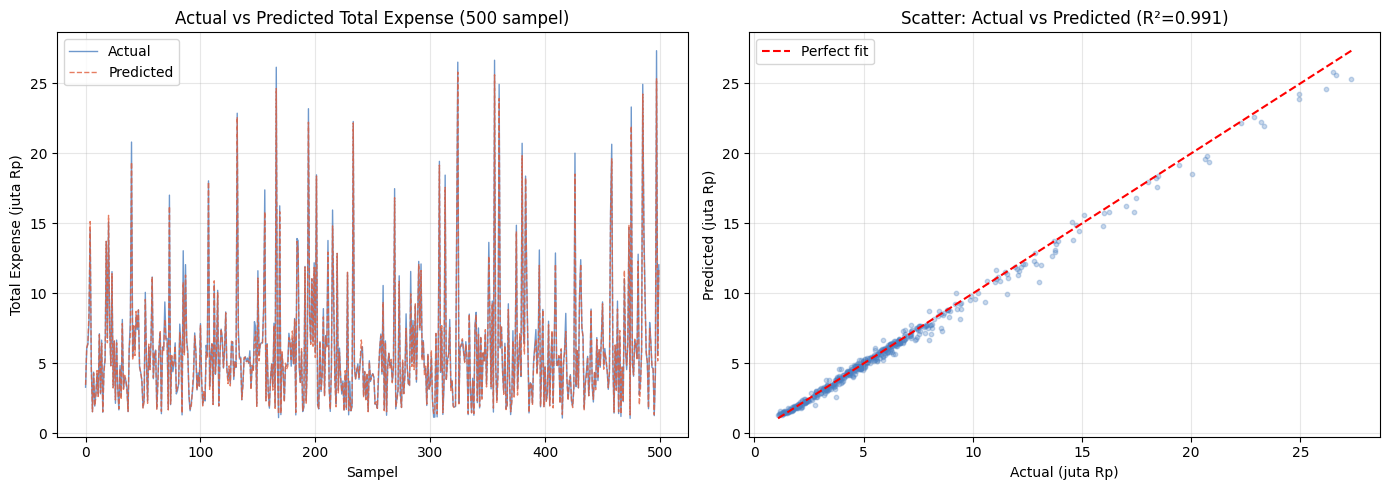

In [11]:
# ──────────────────────────────────────────────────────────────────────
# VISUALISASI — Actual vs Predicted (sample 500 rows)
# ──────────────────────────────────────────────────────────────────────

idx  = np.random.choice(len(y_test), size=min(500, len(y_test)), replace=False)
y_s  = np.array(y_test)[idx]
yp_s = y_pred[idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(y_s/1e6,  label="Actual",    color="#4A7FC0", alpha=0.8, linewidth=1)
axes[0].plot(yp_s/1e6, label="Predicted", color="#E05C3A", alpha=0.8, linewidth=1, linestyle="--")
axes[0].set_title("Actual vs Predicted Total Expense (500 sampel)", fontsize=12)
axes[0].set_xlabel("Sampel"); axes[0].set_ylabel("Total Expense (juta Rp)")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].scatter(y_s/1e6, yp_s/1e6, alpha=0.3, s=10, color="#4A7FC0")
mn, mx = min(y_s.min(), yp_s.min())/1e6, max(y_s.max(), yp_s.max())/1e6
axes[1].plot([mn, mx], [mn, mx], "r--", linewidth=1.5, label="Perfect fit")
axes[1].set_title(f"Scatter: Actual vs Predicted (R²={r2:.3f})", fontsize=12)
axes[1].set_xlabel("Actual (juta Rp)"); axes[1].set_ylabel("Predicted (juta Rp)")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

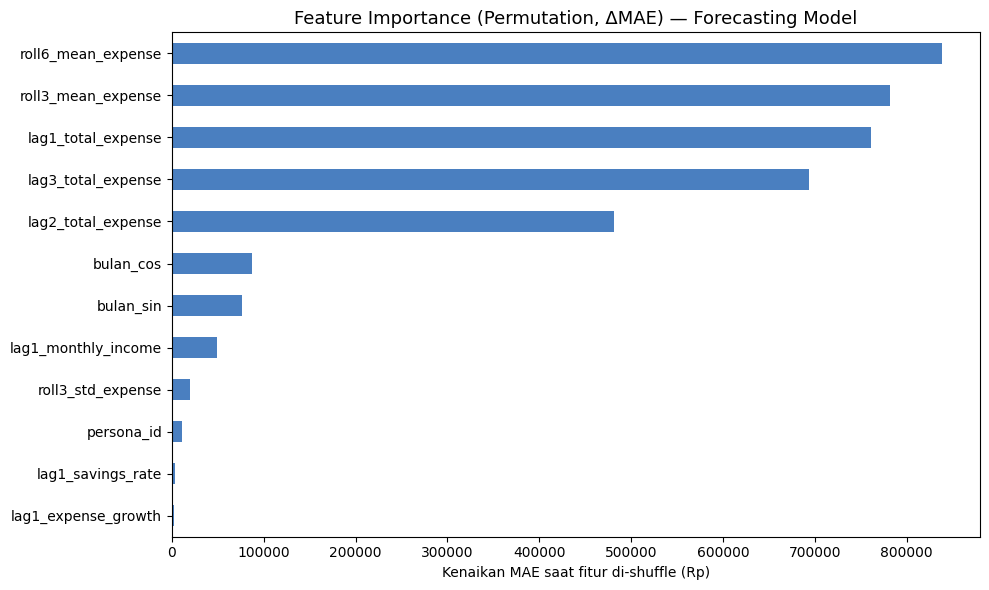


Top 5 features:
roll6_mean_expense    837930.638125
roll3_mean_expense    781309.808775
lag1_total_expense    761419.748050
lag3_total_expense    694104.530175
lag2_total_expense    480967.883550


In [12]:
# ──────────────────────────────────────────────────────────────────────
# FEATURE IMPORTANCE — permutation importance (model-agnostik)
# (Keras tidak punya feature_importances_ bawaan seperti XGBoost,
#  jadi kita pakai permutation importance pada subset test.)
# ──────────────────────────────────────────────────────────────────────

rng = np.random.default_rng(42)
sample_idx = rng.choice(len(X_test_s), size=min(5000, len(X_test_s)), replace=False)
X_perm = X_test_s[sample_idx].copy()
y_perm = y_test.values[sample_idx]

base_pred = model_b.predict(X_perm, verbose=0).ravel() * Y_SCALE
base_mae  = mean_absolute_error(y_perm, base_pred)

importances = []
for j, fname in enumerate(FEATURE_COLS):
    X_shuf = X_perm.copy()
    rng.shuffle(X_shuf[:, j])
    pred_shuf = model_b.predict(X_shuf, verbose=0).ravel() * Y_SCALE
    shuf_mae  = mean_absolute_error(y_perm, pred_shuf)
    importances.append(shuf_mae - base_mae)

fi = pd.Series(importances, index=FEATURE_COLS).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
fi.plot(kind="barh", color="#4A7FC0")
plt.title("Feature Importance (Permutation, ΔMAE) — Forecasting Model", fontsize=13)
plt.xlabel("Kenaikan MAE saat fitur di-shuffle (Rp)")
plt.tight_layout()
plt.show()

print("\nTop 5 features:")
print(fi.sort_values(ascending=False).head(5).to_string())

In [13]:
# ──────────────────────────────────────────────────────────────────────
# FUNGSI PENSION DURABILITY
# ──────────────────────────────────────────────────────────────────────

def estimate_pension_durability(
    monthly_savings,
    current_balance,
    age,
    retirement_age=55,
    life_expectancy=75,
    annual_inflation=0.036
):
    """Estimasi berapa lama dana pensiun bertahan (dalam tahun)."""
    years_to_retire     = max(0, retirement_age - age)
    total_at_retire     = current_balance + monthly_savings * 12 * years_to_retire
    monthly_need_now    = monthly_savings * 0.70
    monthly_need_retire = monthly_need_now * ((1 + annual_inflation) ** years_to_retire)
    annual_burn         = monthly_need_retire * 12
    if annual_burn <= 0:
        return float("inf")
    return round(total_at_retire / annual_burn, 1)

print("Demo Pension Durability:")
cases = [
    {"name":"Fresh Grad JKT",      "monthly_savings":500_000,   "balance":2_000_000,   "age":24},
    {"name":"Karyawan Mapan",       "monthly_savings":3_000_000, "balance":50_000_000,  "age":35},
    {"name":"Profesional Senior",   "monthly_savings":8_000_000, "balance":200_000_000, "age":45},
]
for c in cases:
    dur    = estimate_pension_durability(c["monthly_savings"], c["balance"], c["age"])
    status = "AMAN" if dur >= 20 else ("WASPADA" if dur >= 10 else "KRITIS")
    print(f"  {c['name']}: dana pensiun bertahan ~{dur} tahun → {status}")

Demo Pension Durability:
  Fresh Grad JKT: dana pensiun bertahan ~15.0 tahun → WASPADA
  Karyawan Mapan: dana pensiun bertahan ~15.1 tahun → WASPADA
  Profesional Senior: dana pensiun bertahan ~12.1 tahun → WASPADA


In [15]:
# ──────────────────────────────────────────────────────────────────────
# EXPORT MODEL & METADATA
# ──────────────────────────────────────────────────────────────────────

# 1. Simpan model dalam format .keras
KERAS_MODEL_PATH = os.path.join(OUTPUT_DIR, "model_b.keras")
model_b.save(KERAS_MODEL_PATH)
print(f"✅ Model B berhasil disimpan ke format .keras: {KERAS_MODEL_PATH}")

# 2. Simpan scaler & konfigurasi ke dalam satu file metadata.json
# File ini merangkum semua informasi yang dibutuhkan saat inference
metadata_dict = {
    "model_name": "Time-Series Forecasting Model (Model B)",
    "target_col": TARGET_COL,
    "feature_cols": FEATURE_COLS,
    "scaler_mean": scaler_X.mean_.tolist(),
    "scaler_scale": scaler_X.scale_.tolist(),
    "y_scale": Y_SCALE if 'Y_SCALE' in locals() else None  # jika Anda menggunakan scaling untuk Y
}

METADATA_PATH = os.path.join(OUTPUT_DIR, "metadata.json")
with open(METADATA_PATH, "w") as f:
    json.dump(metadata_dict, f, indent=4)
print(f"✅ Metadata berhasil disimpan ke: {METADATA_PATH}")

# ──────────────────────────────────────────────────────────────────────
# Demo inference (paritas dengan implementasi di frontend)
# ──────────────────────────────────────────────────────────────────────
def predict_total_expense(features_dict):
    """Prediksi total_expense (IDR) dari dictionary fitur.
    Urutan fitur harus mengikuti FEATURE_COLS."""
    x = np.array([[features_dict[c] for c in FEATURE_COLS]], dtype=np.float32)
    x_s = (x - scaler_X.mean_) / scaler_X.scale_
    pred_scaled = model_b.predict(x_s.astype(np.float32), verbose=0).ravel()[0]
    return float(pred_scaled * Y_SCALE)

sample_row = df_test[FEATURE_COLS + [TARGET_COL]].iloc[0].to_dict()
actual = sample_row.pop(TARGET_COL)
pred   = predict_total_expense(sample_row)
print(f"\nDemo inference (1 sampel dari test set):")
print(f"  Actual    : Rp{actual:,.0f}")
print(f"  Predicted : Rp{pred:,.0f}")
print(f"  Selisih   : Rp{abs(actual - pred):,.0f}")

✅ Model B berhasil disimpan ke format .keras: /content/drive/MyDrive/Capstone Projek/models/model_b.keras
✅ Metadata berhasil disimpan ke: /content/drive/MyDrive/Capstone Projek/models/metadata.json

Demo inference (1 sampel dari test set):
  Actual    : Rp5,797,900
  Predicted : Rp5,700,678
  Selisih   : Rp97,222
